---
title: "Lecture 7: Normal Distribution, Joint PDFs"
author: "Jamie Haddock"
format:
    revealjs:
        output-file: Lecture7_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
        slide-level: 3
    html:
        code-fold: true
        embed-resources: true
        output-file: Lecture7
        code-links:
          - text: "Open in Colab"
            href: "https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main/07_normal-distribution-joint-pdfs.ipynb"
            icon: "laptop"
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        output-file: Lecture7
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"
  gh-repo: "Math-151-Probability"
filters:
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

In [1]:
# | echo: false

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad, dblquad
rng = np.random.default_rng(151)
plt.rcParams["figure.dpi"] = 110

# Normal Distribution

## Why the normal distribution?

Thus far, we've seen two continuous distributions -- the **Uniform** (equally likely along an interval) and the **Exponential** (waiting times, memorylessness).

The **Normal** (or **Gaussian**) distribution is a little different than these -- it arises naturally as the *universal limit* of averaging many small, independent effects — measurement error, heights, exam scores, noise in a communication channel. We'll make this precise later in the course (the **Central Limit Theorem**).

. . .

It is (one of) the most important distribution(s) in probability and statistics.

## Normal random variables: definition

::: {.callout-note}
## Definition: Normal random variable
A continuous random variable $X$ is **normal** (or **Gaussian**) with parameters $\mu \in \mathbb{R}$ and $\sigma^2 > 0$, written $X \sim N(\mu, \sigma^2)$, if it has PDF

$$
f_X(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \qquad x \in \mathbb{R}.
$$
:::

. . . 

- The density is a symmetric "bell curve" centered at $\mu$.
- $\sigma$ controls the spread: small $\sigma$ gives a tall, narrow bump; large $\sigma$ gives a short, wide one.
- It's not obvious from the formula alone that this integrates to $1$ — that relies on the classical **Gaussian integral** $\int_{-\infty}^{\infty} e^{-u^2/2}\,du = \sqrt{2\pi}$, which we'll take as known and verify numerically below.

---

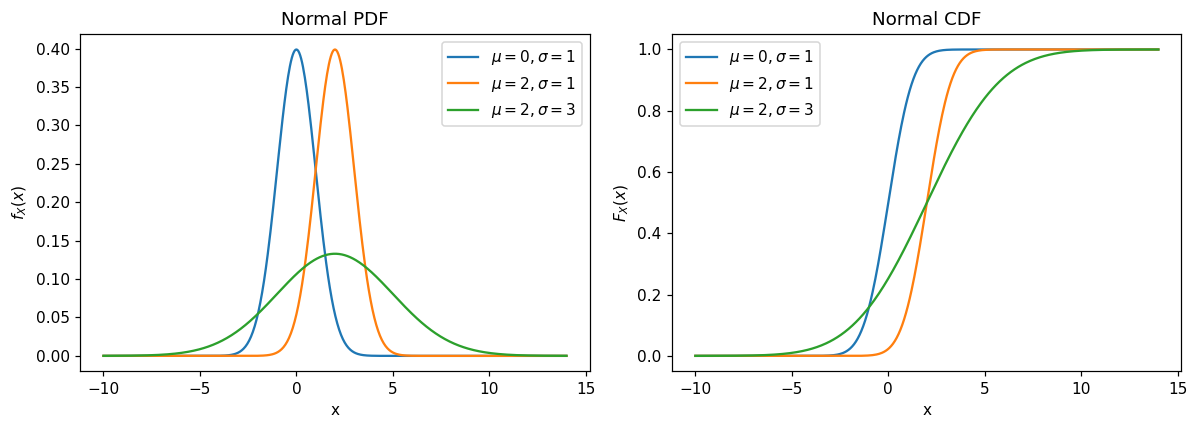

In [2]:
# Visualizing the PDF and CDF for a few choices of (mu, sigma)
xs = np.linspace(-10, 14, 500)
params = [(0, 1), (2, 1), (2, 3)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for mu, sigma in params:
    axes[0].plot(xs, stats.norm.pdf(xs, mu, sigma), label=fr"$\mu={mu}, \sigma={sigma}$")
    axes[1].plot(xs, stats.norm.cdf(xs, mu, sigma), label=fr"$\mu={mu}, \sigma={sigma}$")

axes[0].set_title("Normal PDF"); axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$f_X(x)$"); axes[0].legend()
axes[1].set_title("Normal CDF"); axes[1].set_xlabel("x"); axes[1].set_ylabel(r"$F_X(x)$"); axes[1].legend()
plt.tight_layout()
plt.show()

---

### Mean and variance of normal RV

::: {.callout-tip}
## Fact
If $X \sim N(\mu, \sigma^2)$, then
$$
E[X] = \mu, \qquad \operatorname{Var}(X) = \sigma^2.
$$
:::



. . .

**$E[X] = \mu$:** substitute $u = x - \mu$. The density becomes symmetric in $u$ about $0$, i.e. $f_X(\mu + u) = f_X(\mu - u)$, and

$$
E[X] - \mu = E[X - \mu] = \int_{-\infty}^{\infty} u \cdot \frac{1}{\sigma\sqrt{2\pi}} e^{-u^2/(2\sigma^2)}\, du = 0,
$$

because the integrand is an **odd function** of $u$.

. . .

**$\operatorname{Var}(X) = \sigma^2$:** this takes an integration-by-parts argument on $\int u^2 e^{-u^2/(2\sigma^2)}\,du$.

---

### Normality is preserved by linear transformations

::: {.callout-note}
## Theorem
If $X \sim N(\mu, \sigma^2)$ and $Y = aX + b$ for constants $a \neq 0, b$, then
$$
Y \sim N(a\mu + b,\ a^2\sigma^2).
$$
:::

<details>
<summary>Proof</summary>

Recall if $g$ is invertible and differentiable with inverse $h = g^{-1}$, then $f_Y(y) = f_X(h(y))\,|h'(y)|$. Here $g(x) = ax+b$, so $h(y) = (y-b)/a$ and $h'(y) = 1/a$. Then

$$
f_Y(y) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{\left(\frac{y-b}{a} - \mu\right)^2}{2\sigma^2}\right) \cdot \frac{1}{|a|}
= \frac{1}{|a|\sigma\sqrt{2\pi}} \exp\left(-\frac{(y - (a\mu+b))^2}{2a^2\sigma^2}\right),
$$

which is exactly the $N(a\mu+b,\ a^2\sigma^2)$ density. $\blacksquare$
</details>



. . .

A linear function of a normal random variable is *again normal* — this is a special structural property that most distributions don't have (e.g., a linear function of a Uniform or Exponential RV is generally *not* Uniform or Exponential).

## The standard normal random variable

::: {.callout-note}
## Definition: Standard normal
$Z \sim N(0,1)$ is the **standard normal** random variable. Its PDF and CDF are denoted by lower- and uppercase phis:

$$
\varphi(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}, \qquad \Phi(z) = \int_{-\infty}^z \varphi(t)\, dt.
$$
:::

$\Phi$ has no closed form in terms of elementary functions — historically this is why every probability textbook has a **standard normal table**:

| $z$ | 0.00 | 0.50 | 1.00 | 1.50 | 1.645 | 2.00 |
|---|---|---|---|---|---|---|
| $\Phi(z)$ | 0.5000 | 0.6915 | 0.8413 | 0.9332 | 0.9500 | 0.9772 |

. . .

You can use `scipy.stats.norm` to play the role of the table, but the *method* — standardize, then look up — is exactly what you'd do with a printed table.

---

### Standardizing a normal random variable




::: {.callout-note}
## Corollary (of the linear-transformation theorem)
If $X \sim N(\mu, \sigma^2)$, then

$$
Z = \frac{X - \mu}{\sigma} \sim N(0, 1).
$$

:::


This is immediate from the theorem two slides ago with $a = 1/\sigma$, $b = -\mu/\sigma$: $a\mu + b = 0$ and $a^2\sigma^2 = 1$.



. . .

This lets us answer probability questions about *any* normal $X\sim N(\mu,\sigma^2)$ using only the single function $\Phi$!

$$
P(X \le x) = P\!\left(\frac{X-\mu}{\sigma} \le \frac{x - \mu}{\sigma}\right) = \Phi\!\left(\frac{x-\mu}{\sigma}\right).
$$

---

### Example: snowfall

Annual snowfall $X$ (in inches) at a mountain resort is modeled as $X \sim N(60, 20^2)$.

**(a)** What's the probability of more than 90 inches of snow this year?



. . . 

$$
P(X > 90) = 1 - \Phi\!\left(\frac{90-60}{20}\right) = 1 - \Phi(1.5).
$$

. . .

**(b)** How much snow is exceeded in only 5% of years — i.e. find $x^\star$ with $P(X > x^\star) = 0.05$?

. . .

$$
1 - \Phi\!\left(\frac{x^\star - 60}{20}\right) = 0.05 \iff \Phi\!\left(\frac{x^\star-60}{20}\right) = 0.95 \iff \frac{x^\star - 60}{20} = 1.645
$$

using the table value $\Phi(1.645) \approx 0.95$ — so $x^\star \approx 60 + 20(1.645) = 92.9$ inches.

In [5]:
mu, sigma = 60.0, 20.0

# (a)
p_over_90 = 1 - stats.norm.cdf((90 - mu) / sigma)
print(f"(a) P(X > 90)  = {p_over_90:.4f}   [table method: 1 - Phi(1.5) = {1 - 0.9332:.4f}]")

# (b) 95th percentile
z95 = stats.norm.ppf(0.95)
x_star = mu + sigma * z95
print(f"(b) z with Phi(z)=0.95:  {z95:.3f}")
print(f"    x* (95th percentile) = {x_star:.2f} inches")

(a) P(X > 90)  = 0.0668   [table method: 1 - Phi(1.5) = 0.0668]
(b) z with Phi(z)=0.95:  1.645
    x* (95th percentile) = 92.90 inches


---

### Example: signal detection

A transmitter sends a bit $s \in \{-1, +1\}$ (equally likely) over a noisy channel. The receiver observes

$$
Y = s + N, \qquad N \sim N(0, \sigma^2) \text{ independent of } s,
$$

and decides "$+1$ was sent" if $Y > 0$, and "$-1$ was sent" otherwise.

::: {.callout-warning}
## Question
What is the probability the receiver makes an error?
:::



. . .

By symmetry it suffices to compute the error probability given $s = +1$ was sent (the case $s=-1$ is identical by symmetry of the noise):

$$
P(\text{error} \mid s=1) = P(Y < 0 \mid s=1) = P(1 + N < 0) = P(N < -1) = \Phi\!\left(\frac{-1}{\sigma}\right).
$$

So $P(\text{error}) = \Phi(-1/\sigma)$ — smaller noise $\sigma$ (relative to the signal strength $1$) means a more reliable channel, exactly as intuition demands.

---

P(error) = Phi(-1/sigma) = 0.0228   (sigma = 0.5)
P(error), simulated       = 0.0228


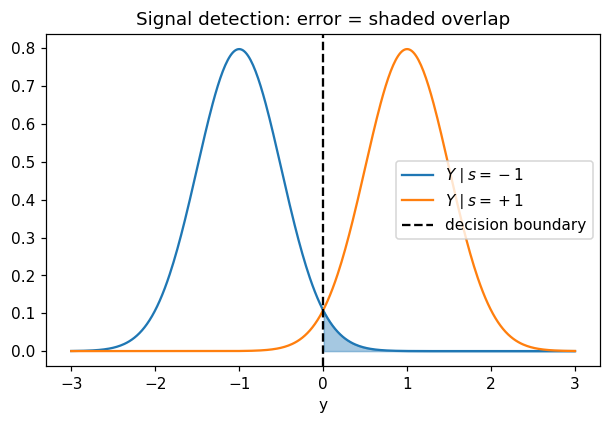

In [6]:
sigma = 0.5
p_error_formula = stats.norm.cdf(-1 / sigma)
print(f"P(error) = Phi(-1/sigma) = {p_error_formula:.4f}   (sigma = {sigma})")

# Verify by simulation
n = 2_000_000
s = rng.choice([-1, 1], size=n)
N = rng.normal(0, sigma, size=n)
Y = s + N
decision = np.where(Y > 0, 1, -1)
p_error_sim = np.mean(decision != s)
print(f"P(error), simulated       = {p_error_sim:.4f}")

# Visualize the two conditional densities and the decision boundary
y_grid = np.linspace(-3, 3, 400)
plt.figure(figsize=(6.5, 4))
plt.plot(y_grid, stats.norm.pdf(y_grid, -1, sigma), label=r"$Y \mid s=-1$")
plt.plot(y_grid, stats.norm.pdf(y_grid, 1, sigma), label=r"$Y \mid s=+1$")
plt.axvline(0, color="k", linestyle="--", label="decision boundary")
plt.fill_between(y_grid[y_grid > 0], 0, stats.norm.pdf(y_grid[y_grid > 0], -1, sigma),
                  alpha=0.4, color="C0")
plt.legend(); plt.xlabel("y"); plt.title("Signal detection: error = shaded overlap")
plt.show()

# Joint PDFs

## Joint PDF of continuous random variables

::: {.callout-note}
## Definition: Joint PDF
Random variables $X, Y$ are **jointly continuous** with **joint PDF** $f_{X,Y}(x,y)$ if $f_{X,Y}(x,y) \ge 0$ everywhere,

$$
\iint_{\mathbb{R}^2} f_{X,Y}(x,y)\, dx\, dy = 1,
$$

and for every (nice) region $B \subseteq \mathbb{R}^2$,

$$
P\big((X,Y) \in B\big) = \iint_B f_{X,Y}(x,y)\, dx\, dy.
$$
:::

. . .

::: {.callout-note}
## Definition: Marginal PDF
$$
f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y)\, dy, \qquad f_Y(y) = \int_{-\infty}^{\infty} f_{X,Y}(x,y)\, dx.
$$
:::

. . .

These are the continuous analogs of the discrete cases -- sums become integrals!

---

### Example: a 2D uniform density

Let $(X,Y)$ be **uniform on the unit disk** $D = \{(x,y): x^2+y^2 \le 1\}$, i.e.

$$
f_{X,Y}(x,y) = \begin{cases} \dfrac{1}{\pi} & (x,y) \in D \\[4pt] 0 & \text{otherwise,}\end{cases}
$$

since the disk has area $\pi$. What is the marginal $f_X(x)$?



. . .

$$
f_X(x) = \int_{-\sqrt{1-x^2}}^{\sqrt{1-x^2}} \frac{1}{\pi}\, dy = \frac{2\sqrt{1-x^2}}{\pi}, \qquad -1 \le x \le 1.
$$

. . .

::: {.callout-warning}
Even though the **joint** density is perfectly flat (uniform), the **marginal** density of $X$ alone is *not* uniform — it's largest at $x=0$ (where the disk is widest) and tapers to $0$ at $x=\pm 1$. Marginalizing a uniform joint density does not generally give a uniform marginal!
:::

---

### Example: Buffon's needle

A floor is ruled with parallel lines a distance $d$ apart. A needle of length $L \le d$ is dropped at random. What's the probability it crosses a line?

**Setup.** Let $X$ = distance from the needle's center to the nearest line, and $\Theta$ = acute angle the needle makes with the lines. A "random drop" means

$$
X \sim \text{Uniform}(0, d/2), \qquad \Theta \sim \text{Uniform}(0, \pi/2), \qquad X, \Theta \text{ independent},
$$

so the joint PDF is $f_{X,\Theta}(x,\theta) = \dfrac{1}{(d/2)}\cdot\dfrac{1}{(\pi/2)} = \dfrac{4}{\pi d}$ on the rectangle $[0,d/2]\times[0,\pi/2]$.



. . .

The needle **crosses a line** exactly when $X \le \tfrac{L}{2}\sin\Theta$ (the needle's half-length, projected perpendicular to the lines, reaches past the center to the line). So

$$
P(\text{cross}) = \iint_{\{x \le \frac{L}{2}\sin\theta\}} \frac{4}{\pi d}\, dx\, d\theta
= \frac{4}{\pi d}\int_0^{\pi/2} \frac{L}{2}\sin\theta\, d\theta
= \frac{4}{\pi d}\cdot \frac{L}{2} \cdot 1 = \frac{2L}{\pi d}.
$$

---

::: {.callout-note}
Solving for $\pi$: $\ \pi = \dfrac{2L}{d \cdot P(\text{cross})}$ — dropping needles gives a (very slow!) randomized way to estimate $\pi$.
:::

In [8]:
L, d = 1.0, 2.0
p_cross_formula = 2 * L / (np.pi * d)
print(f"P(cross), formula = {p_cross_formula:.5f}")

n = 2_000_000
X = rng.uniform(0, d / 2, size=n)
Theta = rng.uniform(0, np.pi / 2, size=n)
crosses = X <= (L / 2) * np.sin(Theta)
p_cross_sim = crosses.mean()
pi_estimate = 2 * L / (d * p_cross_sim)

print(f"P(cross), simulated = {p_cross_sim:.5f}  (n = {n:,} drops)")
print(f"implied estimate of pi = {pi_estimate:.4f}   (true pi = {np.pi:.4f})")

P(cross), formula = 0.31831
P(cross), simulated = 0.31821  (n = 2,000,000 drops)
implied estimate of pi = 3.1426   (true pi = 3.1416)


## Joint CDFs

::: {.callout-note}
## Definition: Joint CDF
$$
F_{X,Y}(x,y) = P(X \le x,\ Y \le y) = \int_{-\infty}^{x}\int_{-\infty}^{y} f_{X,Y}(u,v)\, dv\, du.
$$
:::

Same idea as a single-variable CDF: "accumulated probability," now over a **quadrant** $(-\infty,x]\times(-\infty,y]$ rather than a ray.

---

### Example: uniform on the unit square

Let $(X,Y)$ be uniform on $[0,1]^2$, so $f_{X,Y}(x,y) = 1$ on the square (note: here $X,Y$ *are* independent $\text{Uniform}(0,1)$'s, unlike the disk example). For $0\le x,y\le 1$,

$$
F_{X,Y}(x,y) = \int_0^x\int_0^y 1\, dv\, du = xy.
$$



. . .

**Visual interpretation:** since the density is flat (height 1), $F_{X,Y}(x,y)$ is just the probability mass in the rectangle $[0,x]\times[0,y]$, which — because density is $1$ — equals the *area* of that rectangle, $x \cdot y$.

---

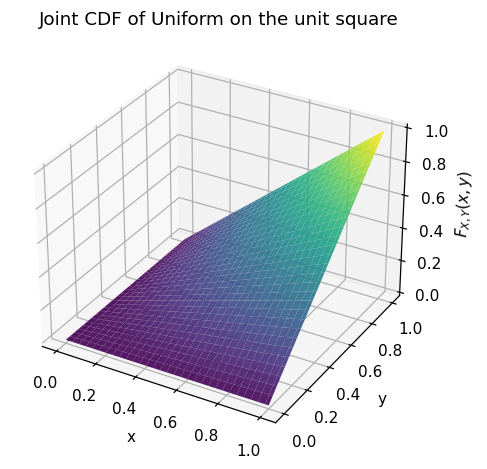

F(0.3, 0.7) via dblquad = 0.2100   (formula x*y = 0.2100)


In [9]:
# Visualize F(x,y) = xy over the unit square, and check it against numerical integration of f=1
xg = np.linspace(0, 1, 60)
yg = np.linspace(0, 1, 60)
Xg, Yg = np.meshgrid(xg, yg)
Fg = Xg * Yg

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(Xg, Yg, Fg, cmap="viridis", alpha=0.9)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel(r"$F_{X,Y}(x,y)$")
ax.set_title("Joint CDF of Uniform on the unit square")
plt.show()

# spot check at one point via double integration of the density
x0, y0 = 0.3, 0.7
F_numeric, _ = dblquad(lambda v, u: 1.0, 0, x0, 0, y0)
print(f"F(0.3, 0.7) via dblquad = {F_numeric:.4f}   (formula x*y = {x0*y0:.4f})")

## Expectation for jointly continuous RVs

::: {.callout-note}
## Definition: Two-variable LOTUS
$$
E[g(X,Y)] = \iint_{\mathbb{R}^2} g(x,y)\, f_{X,Y}(x,y)\, dx\, dy.
$$
:::

This is the continuous counterpart of the two-variable LOTUS for discrete RVs.

. . .

::: {.callout-tip}
## Fact: Linearity of expectation
For any jointly continuous $X, Y$ (independent or not!) and constants $a, b, c$,
$$
E[aX + bY + c] = aE[X] + bE[Y] + c.
$$
:::

Again, this needs **no independence assumption** — it follows immediately by taking $g(x,y) = ax+by$ in the two-variable LOTUS and using linearity of the double integral.

## Extending to more than two random variables

Everything above extends directly to a collection $X_1, \dots, X_n$: a joint PDF $f_{X_1,\dots,X_n}$ on $\mathbb{R}^n$ that integrates to $1$, marginals obtained by integrating out the variables you don't want, a joint CDF, an $n$-variable LOTUS, and linearity of expectation for *any* linear combination $\sum_i a_i X_i$ — again with no independence required.

---

::: {.callout-note}
## A first look: multivariate Gaussian random variables
A random vector $(X_1,\dots,X_n)$ is (jointly, or **multivariate**) **Gaussian** if every linear combination $\sum_i a_i X_i$ is a (univariate) normal random variable. We write $X \sim N(\mu, \Sigma)$, where $\mu = (E[X_1],\dots,E[X_n])$ and $\Sigma$ is the **covariance matrix** — a natural generalization of $\sigma^2$ that also records how the $X_i$ vary *together*.
:::

. . .

Two facts we'll dig into more soon:

- each individual $X_i$ is itself normal (a marginal of a multivariate Gaussian is Gaussian);
- unlike most joint distributions, the *entire* joint distribution of a multivariate Gaussian depends on only the means and the covariance matrix $\Sigma$.

---

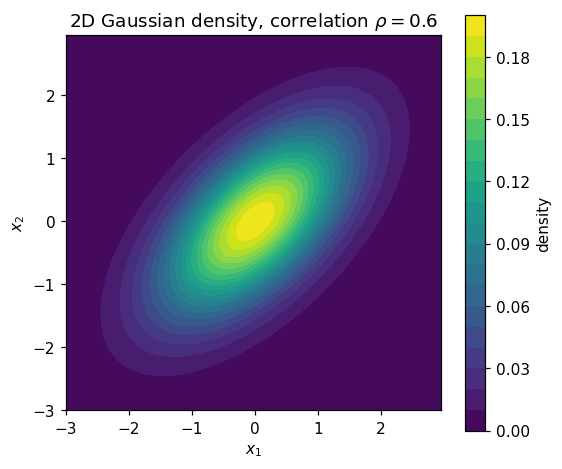

In [11]:
# A visual teaser: a 2D Gaussian with correlated components
rho = 0.6
mean = [0, 0]
cov = [[1, rho], [rho, 1]]

x, y = np.mgrid[-3:3:.05, -3:3:.05]
pos = np.dstack((x, y))
rv = stats.multivariate_normal(mean, cov)

plt.figure(figsize=(5.5, 5))
plt.contourf(x, y, rv.pdf(pos), levels=20, cmap="viridis")
plt.gca().set_aspect("equal")
plt.xlabel(r"$x_1$"); plt.ylabel(r"$x_2$")
plt.title(fr"2D Gaussian density, correlation $\rho={rho}$")
plt.colorbar(label="density")
plt.show()